## 股票市场分析项目

目标：分析几家汽车公司相关的股票数据。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 获取数据
特斯拉股票（纳斯达克股票代码：TSLA）

In [3]:
import pandas_datareader
import datetime

In [4]:
import pandas_datareader.data as web

In [5]:
start = datetime.datetime(2012, 1, 1)
end = datetime.datetime(2017, 1, 1)

In [7]:
tesla = web.DataReader('TSLA', 'stooq', start, end)
tesla.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-12-30,14.4200,14.5000,14.1120,14.2460,69639300
2016-12-29,14.5707,14.6133,14.2750,14.3100,59207790
2016-12-28,14.7687,14.9200,14.4800,14.6493,55285500
2016-12-27,14.3253,14.8167,14.2947,14.6353,85326255
2016-12-23,13.8667,14.2300,13.8473,14.2227,64233720


重复相同的步骤为福特和通用汽车获取数据

In [9]:
ford = web.DataReader('F', 'stooq', start, end)
gm = web.DataReader('GM', 'stooq', start, end)

In [10]:
ford.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-12-30,8.66712,8.69805,8.55395,8.59021,3.869393e+07
2016-12-29,8.67508,8.71662,8.65296,8.66006,2.796503e+07
2016-12-28,8.76259,8.81830,8.65296,8.67508,3.771967e+07
2016-12-27,8.80326,8.85895,8.75552,8.77231,2.740846e+07
2016-12-23,8.80326,8.82271,8.75552,8.82271,2.200639e+07


In [11]:
gm.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-12-30,30.6586,30.7472,30.1908,30.3361,8.780675e+06
2016-12-29,30.6935,30.8936,30.5800,30.5970,5.071263e+06
2016-12-28,31.1216,31.1724,30.5890,30.6069,9.643952e+06
2016-12-27,31.1724,31.2858,30.9116,30.9464,6.874052e+06
2016-12-23,31.1992,31.2350,30.9464,31.0778,1.058165e+07


# 可视化数据

重新创建所有股票开盘价的线性图

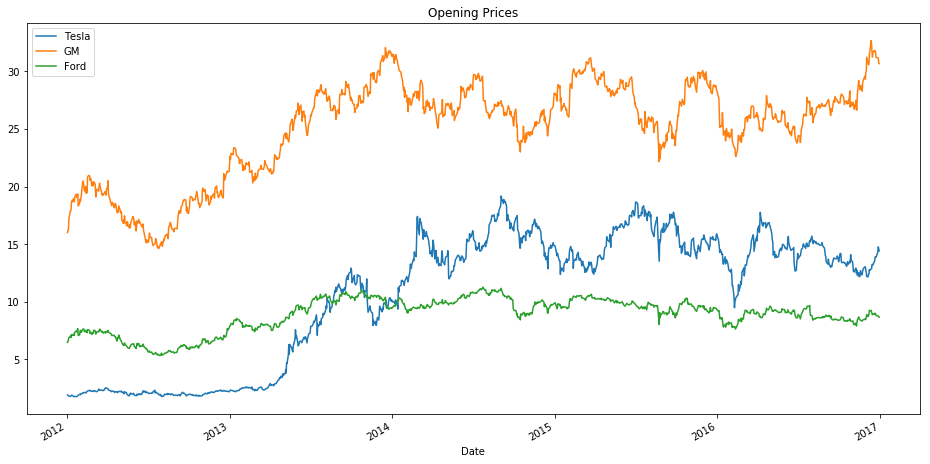

In [12]:
tesla['Open'].plot(label='Tesla', figsize=(16, 8), title='Opening Prices')
gm['Open'].plot(label='GM')
ford['Open'].plot(label='Ford')
plt.legend();

**绘制每天股票交易量**

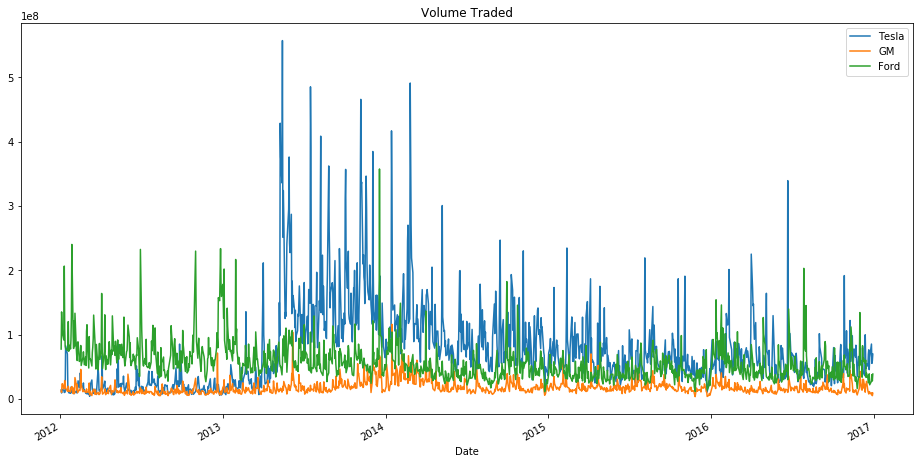

In [13]:
tesla['Volume'].plot(label='Tesla', figsize=(16, 8), title='Volume Traded')
gm['Volume'].plot(label='GM')
ford['Volume'].plot(label='Ford')
plt.legend();

由图得出在2013年底某处出现一个非常大的峰值

In [14]:
ford['Volume'].idxmax()

Timestamp('2013-12-18 00:00:00')

**公开价格时间序列可视化使特斯拉看起来像是一家比通用汽车和福特更有价值的公司。但是要真正理解这一点，我们需要查看公司的总市值，而不仅仅是股价。但目前的数据没有股票总单位的信息，而我们可以做一个简单的计算来试图表示交易总额，那就是用公开价格对交易量列进行多重计算。但是，这仍然不是实际的市值，它只是使用时间序列进行交易的总金额的视觉表示。**

**为每个数据框创建一个名为“总交易量”的新列，即开盘价乘以交易量。**

In [15]:
tesla['Total Traded'] = tesla['Open'] * tesla['Volume']
ford['Total Traded'] = ford['Open'] * ford['Volume']
gm['Total Traded'] = gm['Open'] * gm['Volume']

**对照时间索引绘制此“总交易量”**

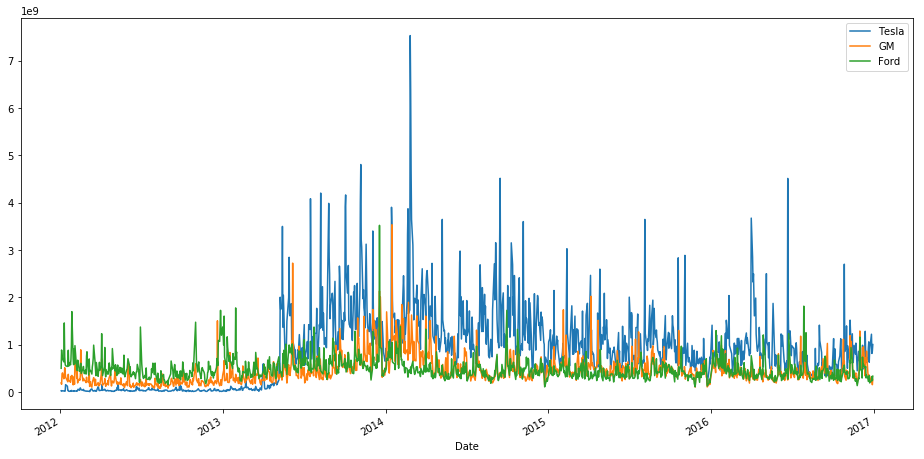

In [16]:
tesla['Total Traded'].plot(label='Tesla', figsize=(16, 8))
gm['Total Traded'].plot(label='GM')
ford['Total Traded'].plot(label='Ford')
plt.legend();

**从图可以得出在2014年初的某个地方有大量资金交易于特斯拉**

In [17]:
tesla['Total Traded'].idxmax()

Timestamp('2014-02-25 00:00:00')

**绘制GM的MA50和MA200**

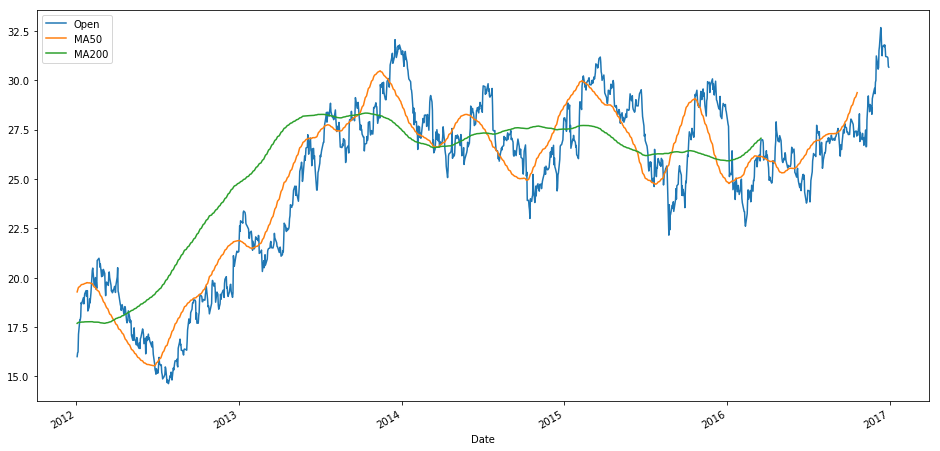

In [18]:
gm['MA50'] = gm['Open'].rolling(50).mean()
gm['MA200'] = gm['Open'].rolling(200).mean()
gm[['Open', 'MA50', 'MA200']].plot(figsize=(16, 8))

In [19]:
 from pandas.plotting import scatter_matrix

In [20]:
car_comp = pd.concat([tesla['Open'], gm['Open'], ford['Open']], axis=1)

In [21]:
car_comp.head()

,Open,Open,Open
Date,,,
2016-12-30,14.4200,30.6586,8.66712
2016-12-29,14.5707,30.6935,8.67508
2016-12-28,14.7687,31.1216,8.76259
2016-12-27,14.3253,31.1724,8.80326
2016-12-23,13.8667,31.1992,8.80326


In [22]:
car_comp.columns = ['Tesla Open', 'GM Open', 'Ford Open']
car_comp.head()

,Tesla Open,GM Open,Ford Open
Date,,,
2016-12-30,14.4200,30.6586,8.66712
2016-12-29,14.5707,30.6935,8.67508
2016-12-28,14.7687,31.1216,8.76259
2016-12-27,14.3253,31.1724,8.80326
2016-12-23,13.8667,31.1992,8.80326


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000029813841DD8>,
      dtype=object)

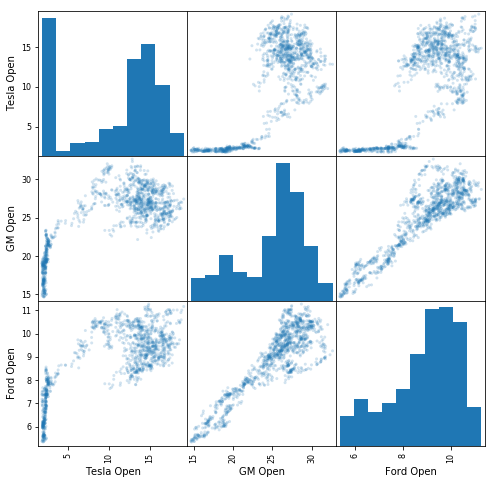

In [23]:
scatter_matrix(car_comp, figsize=(8, 8), alpha=0.2)

**在2012年1月为福特创建烛台图表（日期太多不适合阴阳烛图表）**

In [28]:
from mpl_finance import candlestick_ohlc
from matplotlib.dates import DateFormatter, date2num, WeekdayLocator, DayLocator, MONDAY

In [29]:
ford_reset = ford.loc['2012-01'].reset_index()

In [30]:
ford_reset

,Date,Open,High,Low,Close,Volume,Total Traded
0,2012-01-31,7.37987,7.40250,7.21861,7.34883,7.845932e+07,5.790196e+08
1,2012-01-30,7.13401,7.35963,7.09973,7.27105,9.759822e+07,6.962666e+08
2,2012-01-27,7.07611,7.41266,6.97559,7.22384,2.402438e+08,1.699991e+09
3,2012-01-26,7.67814,7.69104,7.46067,7.53571,1.278774e+08,9.818604e+08
4,2012-01-25,7.53571,7.65011,7.48373,7.61890,9.161847e+07,6.904102e+08
5,2012-01-24,7.39931,7.57737,7.34132,7.55537,7.760485e+07,5.742223e+08
6,2012-01-23,7.47772,7.56640,7.39393,7.46067,8.380366e+07,6.266603e+08
7,2012-01-20,7.39393,7.44829,7.33513,7.41885,7.414895e+07,5.482521e+08
8,2012-01-19,7.35335,7.49559,7.32435,7.43281,1.202541e+08,8.842707e+08
9,2012-01-18,7.08733,7.28838,7.07036,7.27105,7.986263e+07,5.660128e+08


In [31]:
ford_reset['date_ax'] = ford_reset['Date'].apply(lambda date: date2num(date))

In [32]:
ford_reset.head()

,Date,Open,High,Low,Close,Volume,Total Traded,date_ax
0,2012-01-31,7.37987,7.40250,7.21861,7.34883,7.845932e+07,5.790196e+08,734533.0
1,2012-01-30,7.13401,7.35963,7.09973,7.27105,9.759822e+07,6.962666e+08,734532.0
2,2012-01-27,7.07611,7.41266,6.97559,7.22384,2.402438e+08,1.699991e+09,734529.0
3,2012-01-26,7.67814,7.69104,7.46067,7.53571,1.278774e+08,9.818604e+08,734528.0
4,2012-01-25,7.53571,7.65011,7.48373,7.61890,9.161847e+07,6.904102e+08,734527.0


In [33]:
list_of_cols = ['date_ax', 'Open', 'High', 'Low', 'Close']
ford_values = [tuple(vals) for vals in ford_reset[list_of_cols].values]

In [34]:
mondays = WeekdayLocator(MONDAY)
alldays = DayLocator()
weekFormatter = DateFormatter('%b %d')
dayFormatter = DateFormatter('%d')

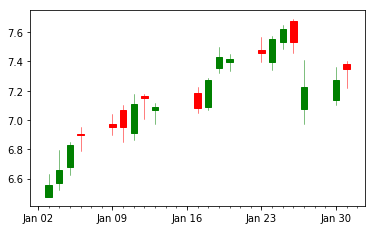

In [35]:
fig, ax = plt.subplots()
fig.subplots_adjust(bottom=0.2)
ax.xaxis.set_major_locator(mondays)
ax.xaxis.set_minor_locator(alldays)
ax.xaxis.set_major_formatter(weekFormatter)
candlestick_ohlc(ax, ford_values, width=0.6, colorup='g', colordown='r');

# 基本财务分析

每日百分比变化由以下公式定义：

rt=ptpt−1−1

这将r_t（时间t的回报）定义为等于时间t的价格除以时间t-1（前一天）的价格减1。基本上，如果你在当天购买股票，然后在第二天出售，这只会告诉你你的收益（或损失）百分比。虽然这不一定有助于试图预测股票的未来价值，但它对分析股票的波动性非常有帮助。如果每日回报分布广泛，股票从一天到下一天的波动性更大。我们通过计算百分比回报，然后用直方图绘制它们，并判断哪只股票最稳定。

**为每个数据帧创建一个名为返回的新列。该列将从收盘价列中计算。有两种方法可以做到这一点，要么使用遵循上述公式的. shift（）方法进行简单计算，要么也可以使用pandas内置的pct_change方法。**

In [36]:
tesla['returns'] = (tesla['Close'] / tesla['Close'].shift(1)) - 1

In [37]:
tesla['returns'] = tesla['Close'].pct_change(1)

In [38]:
ford['returns'] = ford['Close'].pct_change(1)
gm['returns'] = gm['Close'].pct_change(1)

In [39]:
ford.head()

,Open,High,Low,Close,Volume,Total Traded,returns
Date,,,,,,,
2016-12-30,8.66712,8.69805,8.55395,8.59021,3.869393e+07,3.353650e+08,NaN
2016-12-29,8.67508,8.71662,8.65296,8.66006,2.796503e+07,2.425988e+08,0.008131
2016-12-28,8.76259,8.81830,8.65296,8.67508,3.771967e+07,3.305220e+08,0.001734
2016-12-27,8.80326,8.85895,8.75552,8.77231,2.740846e+07,2.412838e+08,0.011208
2016-12-23,8.80326,8.82271,8.75552,8.82271,2.200639e+07,1.937279e+08,0.005745


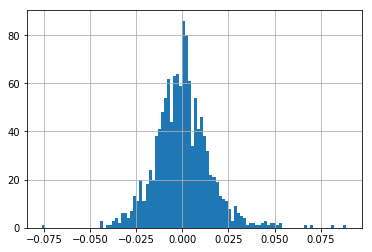

In [40]:
ford['returns'].hist(bins=100)

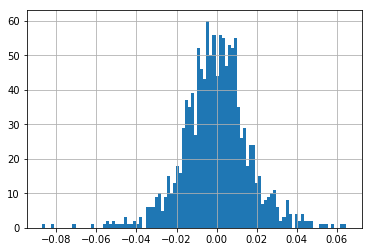

In [41]:
gm['returns'].hist(bins=100)

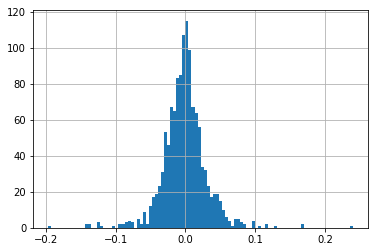

In [42]:
tesla['returns'].hist(bins=100)

**现绘制每家公司回报的直方图。要么分开做，要么把它们叠在一起。根据每日回报的方差来判断哪只股票最不稳定。**

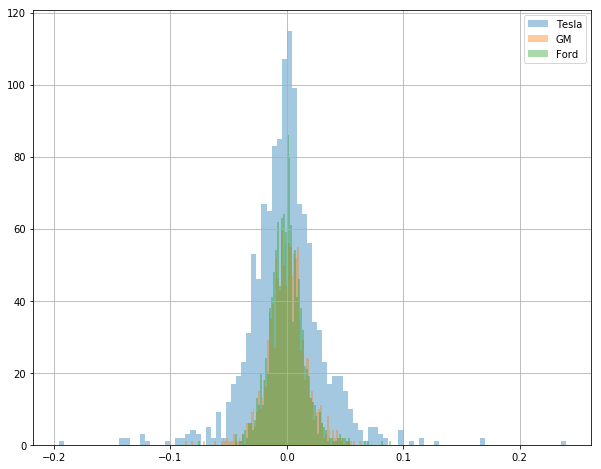

In [43]:
tesla['returns'].hist(bins=100, label='Tesla', figsize=(10,8), alpha=0.4)
gm['returns'].hist(bins=100, label='GM', figsize=(10, 8), alpha=0.4)
ford['returns'].hist(bins=100, label='Ford', figsize=(10, 8), alpha=0.4)
plt.legend()

**也尝试为另一个视点绘制KDE而不是直方图。哪只股票的图最宽？**

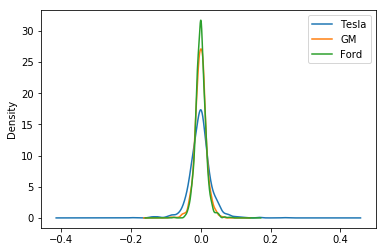

In [44]:
tesla['returns'].plot(kind='kde', label='Tesla')
gm['returns'].plot(kind='kde', label='GM')
ford['returns'].plot(kind='kde', label='Ford')
plt.legend()

**创建一些比较回报的框图。**

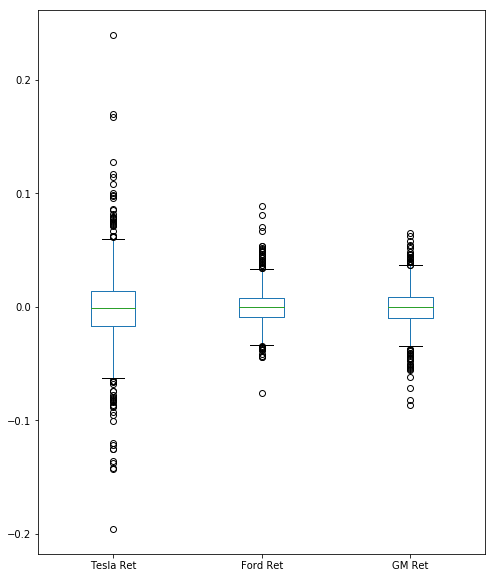

In [45]:
box_df = pd.concat([tesla['returns'], ford['returns'], gm['returns']], axis=1)
box_df.columns = ['Tesla Ret', 'Ford Ret', 'GM Ret']
box_df.plot(kind='box', figsize=(8, 10))

比较股票之间的每日回报

**创建一个散点矩阵图来查看每只股票每日回报之间的相关性。这有助于回答汽车公司有多相关的问题。比如特斯拉正不是开始被市场更多地视为一家科技公司，而不是一家汽车公司？**

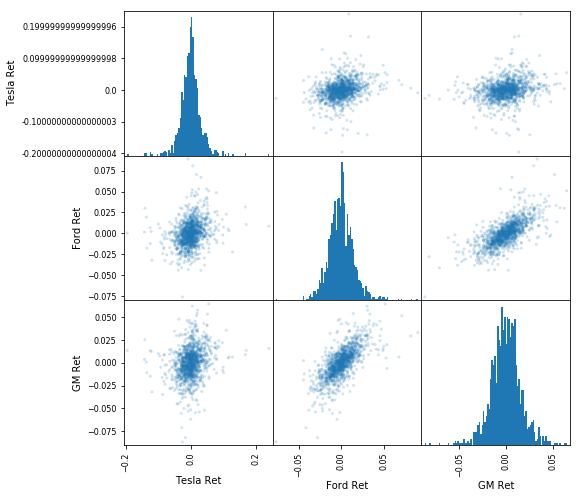

In [46]:
scatter_matrix(box_df, figsize=(8, 8), alpha=0.2, hist_kwds={'bins': 100});

**看起来福特和通用汽车确实有某种可能的关系，我们可以在散点图中绘制这两个相互对抗的图，以便更仔细地观察这一点**

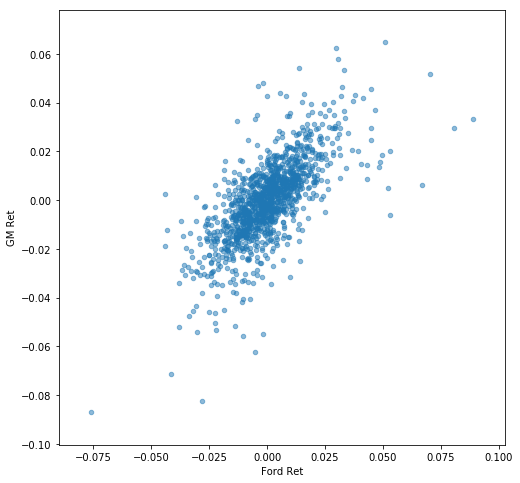

In [47]:
box_df.plot(kind='scatter', x='Ford Ret', y='GM Ret', alpha=0.5, figsize=(8, 8))

现在我们可以看到哪只股票的每日回报范围最广（可以清晰了解到是特斯拉，最初的股价图也很明显反应了这一点）。

对于每日累计回报，如果我们在时间序列开始时在公司投资1美元，今天值多少钱？这与当前的股价不同，因为它会考虑每日回报。我们这里的简单计算不会考虑回馈股息的股票。让我们看一些简单的例子：

假设有一只股票“ABC”正在交易所积极交易。ABC有以下与给定日期相对应的价格

    Date                        Price
    01/01/2018                   10
    01/02/2018                   15
    01/03/2018                   20
    01/04/2018                   25

每日回报：每日回报是股票与前一天相比的利润/损失。（刚刚在上面计算出的）。高于1的值表示利润，类似地，低于1的值表示损失。它也用百分比表示，以更好地传达信息。（当用百分比表示时，如果值高于0，股票就会给你利润或损失）。所以对于上面的例子，每日回报是

    Date                         Daily Return                  %Daily Return
    01/01/2018                 10/10 =  1                          -   
    01/02/2018                 15/10 =  3/2                       50%
    01/03/2018                 20/15 =  4/3                       33%
    01/04/2018                 25/20 =  5/4                       20%

**累积回报**：虽然每日回报很有用，但它并不能让投资者立即了解他迄今为止获得的收益，尤其是在股票非常波动的情况下。累积回报是相对于投资当天计算的。如果累积回报高于 1，则就是在获利，否则将处于亏损状态。因此，对于上述示例，累积收益如下

    Date                       Cumulative Return         %Cumulative Return
    01/01/2018                  10/10 =  1                         100 %   
    01/02/2018                  15/10 =  3/2                       150 %
    01/03/2018                  20/10 =  2                         200 %
    01/04/2018                  25/10 =  5/2                       250 %

累积每日回报的公式为：

我=(1+rt)∗我t−1
 

在这里，我们可以看到我们只是将之前在t-1的i投资乘以1+我们的百分比回报。Pandas使用其Cumprod（）方法使计算变得非常简单。以下列方式使用某物：

df[daily_cumulative_return] = ( 1 + df[pct_daily_return] ).cumprod()
**为每个汽车公司的数据框创建一个累积的每日返回列。**

In [48]:
tesla['Cumulative Return'] = (1 + tesla['returns']).cumprod()
ford['Cumulative Return'] = (1 + ford['returns']).cumprod()
gm['Cumulative Return'] = (1 + gm['returns']).cumprod()

**现在将累积回报列与时间序列指数进行比较。哪只股票显示投资1美元的最高回报？哪只显示最低？**

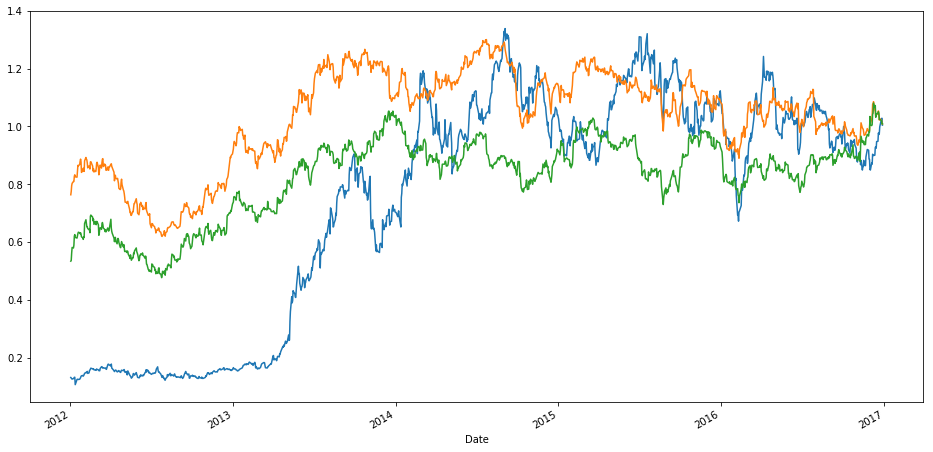

In [49]:
tesla['Cumulative Return'].plot(label='Tesla', figsize=(16, 8))
ford['Cumulative Return'].plot(label='Ford', figsize=(16, 8))
gm['Cumulative Return'].plot(label='GM', figsize=(16, 8))

至此的后半部分完结，这正是我们真正深入研究为时间序列、定量分析、算法交易等设计的功能的地方！